In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [105]:
data=pd.read_csv("/content/sample_data/heart_attack_prediction_dataset.csv")

In [106]:
data.shape

(8763, 26)

In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [109]:
data=data.drop("Patient ID",axis=1)

In [110]:
X=data.drop("Heart Attack Risk",axis=1)
y=data["Heart Attack Risk"]
X_num=X.select_dtypes(include="number")
X_cat=X.select_dtypes(include="object")

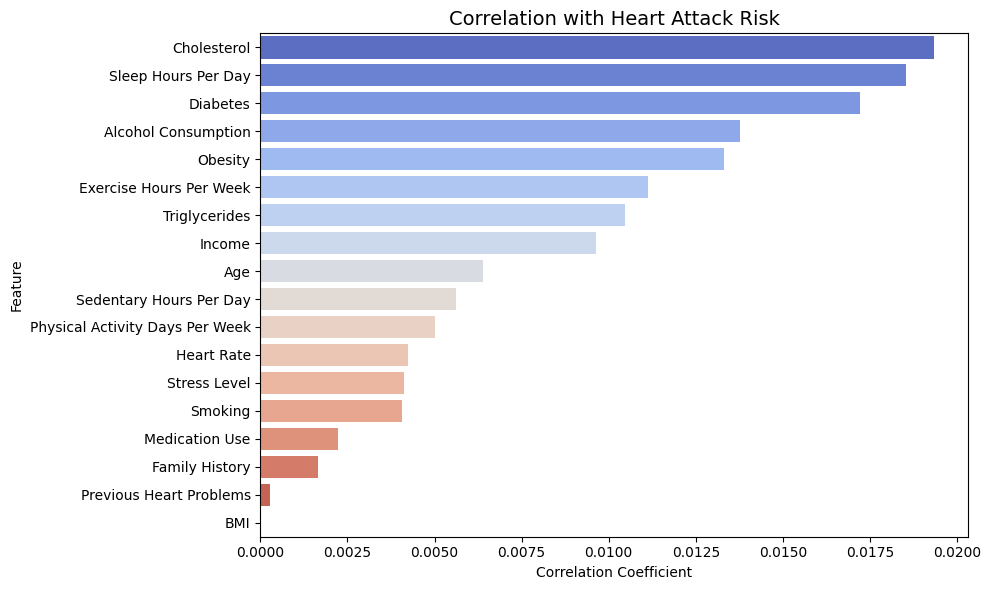

In [111]:

df = X.copy()
df["Heart Attack Risk"] = y

# Convert only numeric columns
df_numeric = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Extract correlation with target
target_corr = corr_matrix["Heart Attack Risk"].drop("Heart Attack Risk")

# Sort by absolute correlation
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr_sorted.values, y=target_corr_sorted.index, palette='coolwarm')
plt.title("Correlation with Heart Attack Risk", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [112]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [113]:
# Keep original X_cat DataFrame
X_cat_df = X_cat.copy()

# Then do the encoding
categorical_cols = X_cat_df.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    X_cat[col] = le.fit_transform(X_cat_df[col])

X_num_df = X_num.copy()

column_transformer_num=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),X_num.columns)
    ],
    remainder="drop"
)
X_num_std=column_transformer_num.fit_transform(X_num_df)
X_num_std=pd.DataFrame(X_num_std,columns=X_num.columns)


In [114]:
X_full=pd.concat([X_num_std,X_cat],axis=1)

In [115]:
from sklearn.model_selection import train_test_split

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [117]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

CV Score: 0.5683694027546167
              precision    recall  f1-score   support

           0       0.57      0.57      0.57      4499
           1       0.57      0.57      0.57      4499

    accuracy                           0.57      8998
   macro avg       0.57      0.57      0.57      8998
weighted avg       0.57      0.57      0.57      8998



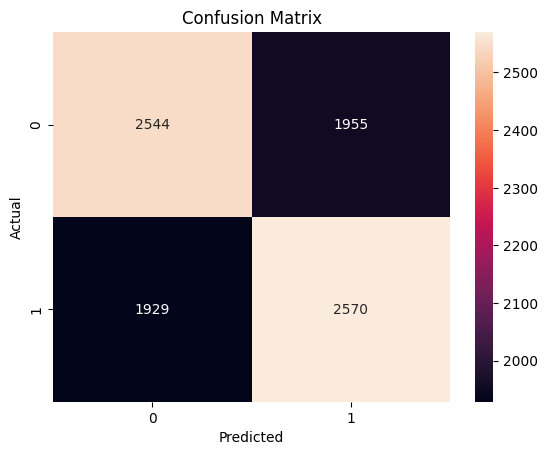

In [118]:
from sklearn.linear_model import LogisticRegression
lr_clf=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_score=cross_val_score(lr_clf,X_train_resampled,y_train_resampled,cv=5)
print("CV Score:",lr_score.mean())
lr_pred=cross_val_predict(lr_clf, X_train_resampled, y_train_resampled, cv=5)
print(classification_report(y_train_resampled,lr_pred))
cm=confusion_matrix(y_train_resampled,lr_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CV Score: 0.6927589401519362
              precision    recall  f1-score   support

           0       0.63      0.91      0.75      4499
           1       0.85      0.47      0.60      4499

    accuracy                           0.69      8998
   macro avg       0.74      0.69      0.68      8998
weighted avg       0.74      0.69      0.68      8998



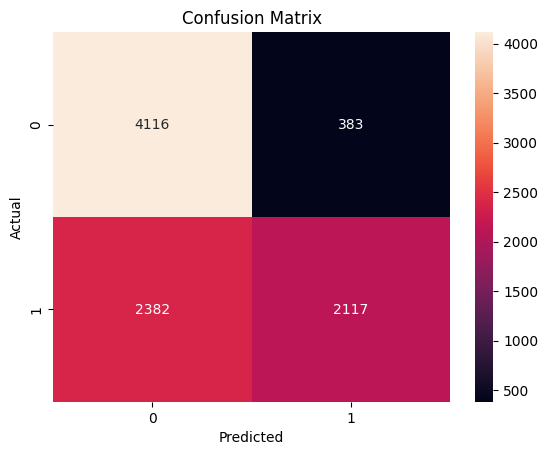

In [119]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
forest_scores = cross_val_score(forest_clf, X_train_resampled, y_train_resampled, cv=5)
print("CV Score:",forest_scores.mean())
forest_pred=cross_val_predict(forest_clf, X_train_resampled, y_train_resampled, cv=5)
print(classification_report(y_train_resampled,forest_pred))
cm=confusion_matrix(y_train_resampled,forest_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CV Score: 0.658741770119202
              precision    recall  f1-score   support

           0       0.63      0.78      0.70      4499
           1       0.71      0.54      0.61      4499

    accuracy                           0.66      8998
   macro avg       0.67      0.66      0.65      8998
weighted avg       0.67      0.66      0.65      8998



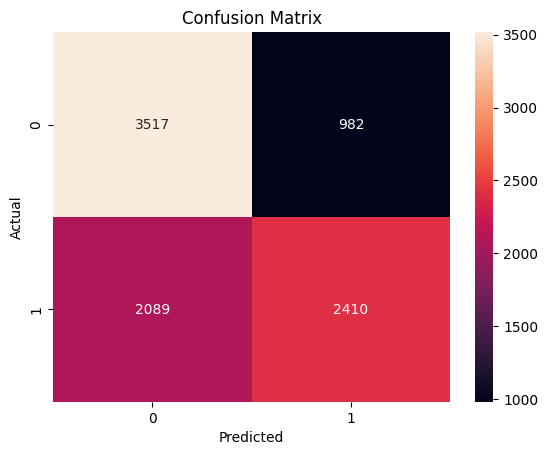

In [120]:
from xgboost import XGBClassifier
xg_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xg_scores = cross_val_score(xg_clf, X_train_resampled, y_train_resampled, cv=5)
print("CV Score:",xg_scores.mean())
xg_pred=cross_val_predict(xg_clf, X_train_resampled, y_train_resampled, cv=5)
print(classification_report(y_train_resampled,xg_pred))
cm=confusion_matrix(y_train_resampled,xg_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CV Score: 0.7940865913161633
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      4499
           1       0.82      0.75      0.78      4499

    accuracy                           0.79      8998
   macro avg       0.80      0.79      0.79      8998
weighted avg       0.80      0.79      0.79      8998



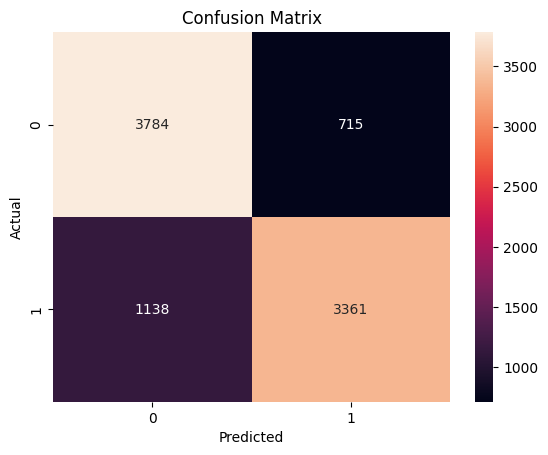

In [121]:
from sklearn.svm import SVC
svm_clf = SVC(gamma="auto", random_state=42,kernel='rbf', class_weight='balanced')
svm_scores = cross_val_score(svm_clf, X_train_resampled, y_train_resampled, cv=5)
print("CV Score:",svm_scores.mean())
svm_pred=cross_val_predict(svm_clf, X_train_resampled, y_train_resampled, cv=5)
print(classification_report(y_train_resampled,svm_pred))
cm=confusion_matrix(y_train_resampled,svm_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()